# Lecture 13: Land Cover Analysis & Vegetation Phenology
## F&W ECOL 458: Environmental Data Science

**Theme:** How can we analyze land cover patterns and track vegetation dynamics through time?

**Duration:** 75 minutes

**Learning Objectives:**
- Work with existing land cover products (NLCD, ESA WorldCover)
- Calculate land cover statistics and analyze spatial patterns
- Understand vegetation phenology concepts
- Build and analyze NDVI time series
- Extract phenological metrics (green-up, peak, senescence)
- Compare phenology across land cover types and years

---

In [ ]:
# Install required packages
!pip install geemap earthengine-api -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.0 MB/s eta 0:00:00


In [ ]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='fwe458')  # Replace with your project ID

In [ ]:
# Study area: Dane County, Wisconsin
dane_county = ee.Geometry.Rectangle([-89.8, 42.85, -89.0, 43.35])

# Sample locations for phenology analysis
forest_point = ee.Geometry.Point([-89.4308, 43.0420])  # UW Arboretum
agriculture_point = ee.Geometry.Point([-89.6000, 43.2500])  # Farm field
urban_point = ee.Geometry.Point([-89.3840, 43.0740])  # Madison downtown

---
## Part 1: Working with Land Cover Products

### 1.1 Introduction to Land Cover Products

Rather than creating our own land cover maps (which requires machine learning), we can use **existing land cover products** created by government agencies and research institutions.

### Major Land Cover Products

| Product | Resolution | Coverage | Classes | Update Frequency |
|---------|------------|----------|---------|------------------|
| **NLCD** | 30 m | USA | 16 | Every 2-3 years |
| **ESA WorldCover** | 10 m | Global | 11 | Annual |
| **MODIS Land Cover** | 500 m | Global | 17 | Annual |
| **Copernicus Global** | 100 m | Global | 23 | Annual |

Today we'll use **NLCD (National Land Cover Database)** for detailed US analysis and **ESA WorldCover** for comparison.

### 1.2 NLCD Land Cover Classes

| Code | Class | Description |
|------|-------|-------------|
| 11 | Open Water | Lakes, rivers, ponds |
| 21 | Developed, Open | <20% impervious (parks, lawns) |
| 22 | Developed, Low | 20-49% impervious (residential) |
| 23 | Developed, Medium | 50-79% impervious |
| 24 | Developed, High | >80% impervious (urban core) |
| 31 | Barren | Rock, sand, clay |
| 41 | Deciduous Forest | >20% deciduous trees |
| 42 | Evergreen Forest | >20% evergreen trees |
| 43 | Mixed Forest | Neither >75% |
| 52 | Shrub/Scrub | Shrubs <5m tall |
| 71 | Grassland | Grasses, not managed |
| 81 | Pasture/Hay | Managed grasses |
| 82 | Cultivated Crops | Row crops |
| 90 | Woody Wetlands | Forested wetlands |
| 95 | Herbaceous Wetlands | Non-forested wetlands |

In [ ]:
# Load NLCD 2021 Land Cover
nlcd = ee.Image('USGS/NLCD_RELEASES/2021_REL/NLCD/2021').select('landcover')

# Clip to study area
nlcd_dane = nlcd.clip(dane_county)

# NLCD color palette (standard colors)
nlcd_palette = [
    '466b9f',  # 11 Open Water
    'd1def8',  # 21 Developed, Open
    'dec5c5',  # 22 Developed, Low
    'd99282',  # 23 Developed, Medium
    'eb0000',  # 24 Developed, High
    'ab0000',  # 31 Barren
    '68ab5f',  # 41 Deciduous Forest
    '1c5f2c',  # 42 Evergreen Forest
    'b5c58f',  # 43 Mixed Forest
    'ccb879',  # 52 Shrub/Scrub
    'dfdfc2',  # 71 Grassland/Herbaceous
    'dcd939',  # 81 Pasture/Hay
    'ab6c28',  # 82 Cultivated Crops
    'b8d9eb',  # 90 Woody Wetlands
    '6c9fb8',  # 95 Emergent Herbaceous Wetlands
]

print("NLCD 2021 loaded!")

NLCD 2021 loaded!


In [ ]:
# Visualize NLCD
Map = geemap.Map(center=[43.1, -89.4], zoom=10)

Map.addLayer(nlcd_dane, {}, 'NLCD 2021')

# Add legend using keys and colors lists
legend_keys = ['Open Water', 'Developed, Open', 'Developed, Low', 'Developed, Med',
               'Developed, High', 'Deciduous Forest', 'Evergreen Forest', 'Mixed Forest',
               'Pasture/Hay', 'Cultivated Crops', 'Woody Wetlands']
legend_colors = ['#466b9f', '#d1def8', '#dec5c5', '#d99282', '#eb0000',
                 '#68ab5f', '#1c5f2c', '#b5c58f', '#dcd939', '#ab6c28', '#b8d9eb']

Map.add_legend(title='NLCD Land Cover', keys=legend_keys, colors=legend_colors)

Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

### 1.3 Calculate Land Cover Statistics

In [ ]:
# Calculate area of each land cover class
area_image = ee.Image.pixelArea().addBands(nlcd_dane)

areas = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(
        groupField=1,
        groupName='class'
    ),
    geometry=dane_county,
    scale=30,
    maxPixels=1e9
).getInfo()

# Class name lookup
class_names = {
    11: 'Open Water',
    21: 'Developed, Open',
    22: 'Developed, Low',
    23: 'Developed, Medium',
    24: 'Developed, High',
    31: 'Barren',
    41: 'Deciduous Forest',
    42: 'Evergreen Forest',
    43: 'Mixed Forest',
    52: 'Shrub/Scrub',
    71: 'Grassland',
    81: 'Pasture/Hay',
    82: 'Cultivated Crops',
    90: 'Woody Wetlands',
    95: 'Herbaceous Wetlands'
}

# Process results
total_area = sum([g['sum'] for g in areas['groups']])

print("Land Cover Area - Dane County, WI (NLCD 2021):")
print(f"{'Class':<22} {'Area (km²)':>12} {'Percent':>10}")
print("=" * 46)

results = []
for group in sorted(areas['groups'], key=lambda x: -x['sum']):
    class_id = int(group['class'])
    area_km2 = group['sum'] / 1e6
    percent = group['sum'] / total_area * 100
    name = class_names.get(class_id, f'Class {class_id}')
    print(f"{name:<22} {area_km2:>12.1f} {percent:>9.1f}%")
    results.append({'class': name, 'area_km2': area_km2, 'percent': percent})

print(f"{'TOTAL':<22} {total_area/1e6:>12.1f} {'100.0%':>10}")

Land Cover Area - Dane County, WI (NLCD 2021):
Class                    Area (km²)    Percent
Cultivated Crops             1813.0      50.1%
Pasture/Hay                   410.7      11.4%
Deciduous Forest              373.3      10.3%
Developed, Low                223.9       6.2%
Developed, Open               163.1       4.5%
Herbaceous Wetlands           161.3       4.5%
Developed, Medium             129.4       3.6%
Open Water                    110.9       3.1%
Mixed Forest                   87.0       2.4%
Woody Wetlands                 70.0       1.9%
Developed, High                42.9       1.2%
Barren                         11.3       0.3%
Evergreen Forest                8.5       0.2%
Shrub/Scrub                     7.3       0.2%
Grassland                       5.0       0.1%
TOTAL                        3617.6     100.0%


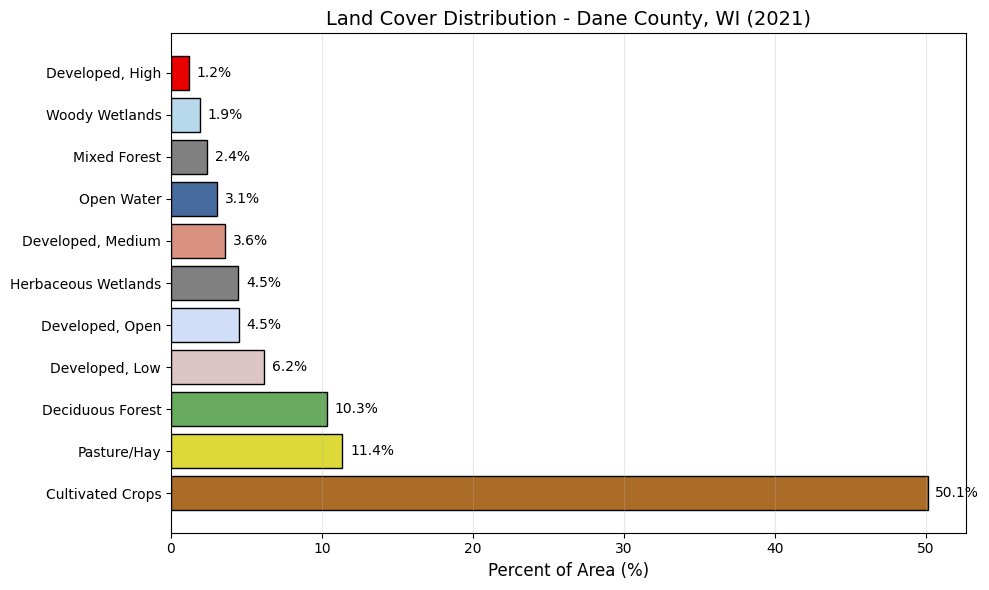

In [ ]:
# Visualize land cover distribution
df_lc = pd.DataFrame(results)
df_lc = df_lc[df_lc['percent'] > 1]  # Only classes > 1%

fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'Cultivated Crops': '#ab6c28',
    'Pasture/Hay': '#dcd939',
    'Deciduous Forest': '#68ab5f',
    'Developed, Low': '#dec5c5',
    'Developed, Open': '#d1def8',
    'Open Water': '#466b9f',
    'Developed, Medium': '#d99282',
    'Woody Wetlands': '#b8d9eb',
    'Grassland': '#dfdfc2',
    'Developed, High': '#eb0000',
}

bar_colors = [colors.get(c, 'gray') for c in df_lc['class']]
bars = ax.barh(df_lc['class'], df_lc['percent'], color=bar_colors, edgecolor='black')

ax.set_xlabel('Percent of Area (%)', fontsize=12)
ax.set_title('Land Cover Distribution - Dane County, WI (2021)', fontsize=14)
ax.grid(True, axis='x', alpha=0.3)

# Add percentage labels
for bar, pct in zip(bars, df_lc['percent']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 1.4 Reclassify and Simplify

In [ ]:
# Create simplified land cover classes
# Remap NLCD classes to simpler categories

# From classes -> To classes
from_classes = [11, 21, 22, 23, 24, 31, 41, 42, 43, 52, 71, 81, 82, 90, 95]
to_classes =   [1,  2,  2,  2,  2,  5,  3,  3,  3,  4,  4,  4,  4,  6,  6]

# 1=Water, 2=Developed, 3=Forest, 4=Agriculture/Grass, 5=Barren, 6=Wetland

nlcd_simple = nlcd_dane.remap(from_classes, to_classes).rename('landcover_simple')

simple_vis = {
    'min': 1,
    'max': 6,
    'palette': ['blue', 'red', 'darkgreen', 'yellow', 'gray', 'cyan']
}

Map = geemap.Map(center=[43.1, -89.4], zoom=10)
Map.addLayer(nlcd_simple, simple_vis, 'Simplified Land Cover')

# Add legend using keys and colors lists
legend_keys = ['Water', 'Developed', 'Forest', 'Agriculture/Grass', 'Barren', 'Wetland']
legend_colors = ['#0000FF', '#FF0000', '#006400', '#FFFF00', '#808080', '#00FFFF']

Map.add_legend(title='Land Cover', keys=legend_keys, colors=legend_colors)
Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

### 1.5 Using Land Cover as a Mask

In [ ]:
# Create masks for specific land cover types
forest_mask = nlcd_dane.eq(41).Or(nlcd_dane.eq(42)).Or(nlcd_dane.eq(43))
agriculture_mask = nlcd_dane.eq(81).Or(nlcd_dane.eq(82))
urban_mask = nlcd_dane.eq(22).Or(nlcd_dane.eq(23)).Or(nlcd_dane.eq(24))

# Visualize forest areas only
Map = geemap.Map(center=[43.1, -89.4], zoom=10)
Map.addLayer(forest_mask.selfMask(), {'palette': ['darkgreen']}, 'Forest Areas')
Map.addLayer(agriculture_mask.selfMask(), {'palette': ['goldenrod']}, 'Agricultural Areas')
Map.addLayer(urban_mask.selfMask(), {'palette': ['red']}, 'Urban Areas')
Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [ ]:
# Calculate average NDVI for different land cover types
# First, get a summer NDVI image
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')

def scale_and_ndvi(image):
    optical = image.select(['SR_B4', 'SR_B5']).multiply(0.0000275).add(-0.2)
    ndvi = optical.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return ndvi

summer_ndvi = (landsat
    .filterDate('2023-06-01', '2023-08-31')
    .filterBounds(dane_county)
    .filter(ee.Filter.lt('CLOUD_COVER', 20))
    .map(scale_and_ndvi)
    .median()
    .clip(dane_county)
)

# Calculate mean NDVI for each land cover type
print("Mean Summer NDVI by Land Cover Type:")
print("=" * 40)

masks = [
    ('Forest', forest_mask),
    ('Agriculture', agriculture_mask),
    ('Urban', urban_mask)
]

for name, mask in masks:
    masked_ndvi = summer_ndvi.updateMask(mask)
    mean_ndvi = masked_ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=dane_county,
        scale=30,
        maxPixels=1e9
    ).get('NDVI').getInfo()
    print(f"  {name:<15}: {mean_ndvi:.3f}")

Mean Summer NDVI by Land Cover Type:
  Forest         : 0.839
  Agriculture    : 0.661
  Urban          : 0.513


---
## Part 2: Vegetation Phenology Analysis

### 2.1 What is Phenology?

**Phenology** is the study of seasonal cycles in living organisms. For vegetation, key phenological events include:

| Event | Definition | Timing (Wisconsin) |
|-------|------------|--------------------|
| **Green-up** | Leaf emergence, rapid NDVI increase | April-May |
| **Peak greenness** | Maximum photosynthetic activity | July-August |
| **Senescence** | Leaf color change and drop | September-October |
| **Dormancy** | Minimum vegetation activity | November-March |

### Why Study Phenology?

- **Climate change indicator**: Earlier spring, longer growing seasons
- **Agricultural management**: Planting and harvest timing
- **Ecosystem function**: Carbon uptake, wildlife habitat
- **Drought monitoring**: Delayed green-up or early senescence

### 2.2 Build NDVI Time Series with MODIS

In [ ]:
# MODIS provides consistent, frequent observations ideal for phenology
# MOD13Q1: 16-day NDVI composite at 250m resolution

modis = ee.ImageCollection('MODIS/061/MOD13Q1')

# Get one full year
modis_2023 = (modis
    .filterDate('2023-01-01', '2023-12-31')
    .filterBounds(dane_county)
    .select('NDVI')
)

print(f"MODIS images in 2023: {modis_2023.size().getInfo()}")
print("(16-day composites = ~23 images per year)")

MODIS images in 2023: 23
(16-day composites = ~23 images per year)


In [ ]:
# Scale MODIS NDVI (stored as integer * 10000)
def scale_modis(image):
    return image.multiply(0.0001).copyProperties(image, ['system:time_start'])

modis_2023 = modis_2023.map(scale_modis)

In [ ]:
# Extract time series at sample points
# Define sample locations with names
sample_sites = [
    {'name': 'Forest (Arboretum)', 'point': forest_point},
    {'name': 'Agriculture', 'point': agriculture_point},
    {'name': 'Urban (Madison)', 'point': urban_point}
]

# Get image dates from collection
image_list = modis_2023.toList(modis_2023.size())
n_images = modis_2023.size().getInfo()

records = []

# Extract NDVI for each site and each image
for site in sample_sites:
    for i in range(n_images):
        image = ee.Image(image_list.get(i))

        # Get date
        date = image.date().format('YYYY-MM-dd').getInfo()

        # Extract NDVI value at point
        value = image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=site['point'],
            scale=250
        ).get('NDVI').getInfo()

        if value is not None:
            records.append({
                'date': date,
                'name': site['name'],
                'NDVI': value
            })

df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df['date'])
df['doy'] = df['date'].dt.dayofyear

print(f"Extracted {len(df)} observations")
df.head()

Extracted 69 observations


,date,name,NDVI,doy
0,2023-01-01,Forest (Arboretum),0.4026,1
1,2023-01-17,Forest (Arboretum),0.0394,17
2,2023-02-02,Forest (Arboretum),0.0240,33
3,2023-02-18,Forest (Arboretum),0.0662,49
4,2023-03-06,Forest (Arboretum),0.0212,65


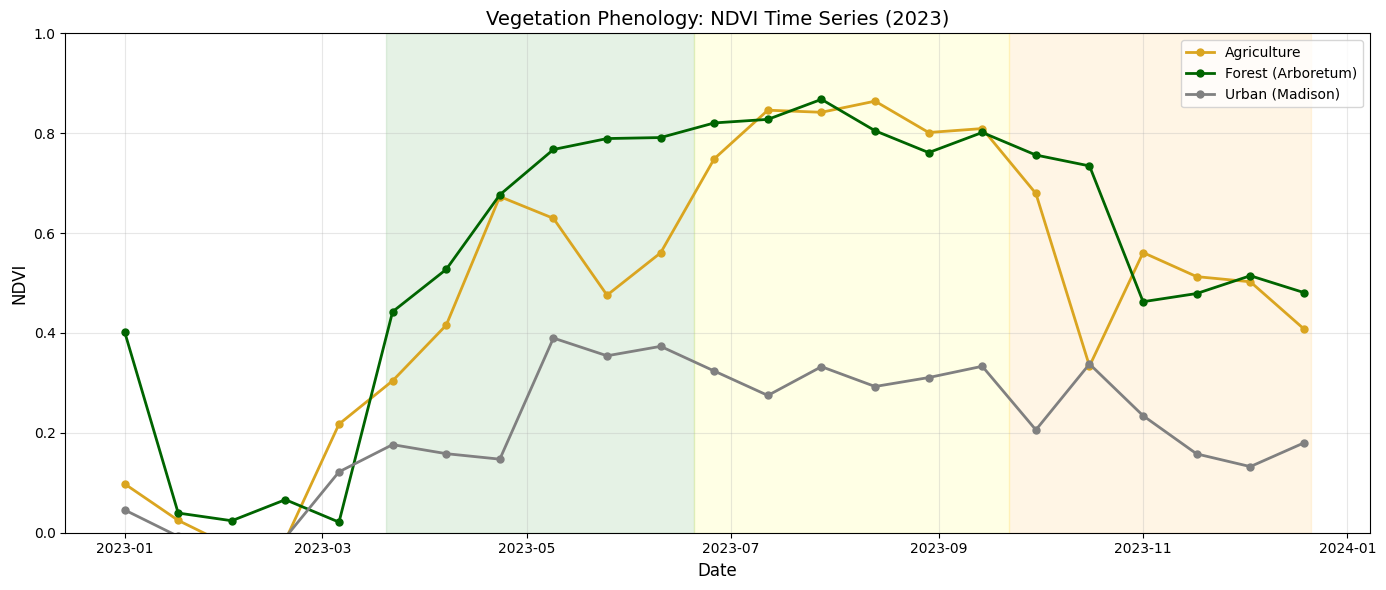

In [ ]:
# Plot NDVI time series for each land cover
fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    'Forest (Arboretum)': 'darkgreen',
    'Agriculture': 'goldenrod',
    'Urban (Madison)': 'gray'
}

for name, group in df.groupby('name'):
    group = group.sort_values('date')
    ax.plot(group['date'], group['NDVI'], 'o-',
            label=name, color=colors[name], linewidth=2, markersize=5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Vegetation Phenology: NDVI Time Series (2023)', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# Add season shading
ax.axvspan(pd.Timestamp('2023-03-20'), pd.Timestamp('2023-06-20'),
           alpha=0.1, color='green', label='Spring')
ax.axvspan(pd.Timestamp('2023-06-20'), pd.Timestamp('2023-09-22'),
           alpha=0.1, color='yellow', label='Summer')
ax.axvspan(pd.Timestamp('2023-09-22'), pd.Timestamp('2023-12-21'),
           alpha=0.1, color='orange', label='Fall')

plt.tight_layout()
plt.show()

### 2.3 Extract Phenological Metrics

Key metrics we can extract from NDVI time series:

| Metric | Definition | Calculation |
|--------|------------|-------------|
| **Start of Season (SOS)** | Green-up date | NDVI crosses threshold (spring) |
| **Peak NDVI** | Maximum greenness | Maximum NDVI value |
| **Peak Date** | Timing of maximum | Date of peak NDVI |
| **End of Season (EOS)** | Senescence date | NDVI drops below threshold (fall) |
| **Growing Season Length** | Duration | EOS - SOS |
| **Amplitude** | Seasonal range | Peak - Minimum NDVI |

In [ ]:
def extract_phenology_metrics(df_site):
    """
    Extract phenological metrics from NDVI time series.

    Parameters:
    -----------
    df_site : DataFrame with 'date', 'doy', and 'NDVI' columns

    Returns:
    --------
    dict : Phenological metrics
    """
    df_site = df_site.sort_values('doy').copy()

    # Smooth the data with rolling mean
    df_site['NDVI_smooth'] = df_site['NDVI'].rolling(window=3, center=True, min_periods=1).mean()

    metrics = {}

    # Peak NDVI and timing
    peak_idx = df_site['NDVI_smooth'].idxmax()
    metrics['peak_ndvi'] = df_site.loc[peak_idx, 'NDVI_smooth']
    metrics['peak_date'] = df_site.loc[peak_idx, 'date']
    metrics['peak_doy'] = df_site.loc[peak_idx, 'doy']

    # Minimum NDVI (winter/dormancy)
    min_idx = df_site['NDVI_smooth'].idxmin()
    metrics['min_ndvi'] = df_site.loc[min_idx, 'NDVI_smooth']

    # Amplitude
    metrics['amplitude'] = metrics['peak_ndvi'] - metrics['min_ndvi']

    # Threshold for SOS/EOS (50% of amplitude above minimum)
    threshold = metrics['min_ndvi'] + 0.5 * metrics['amplitude']

    # Start of Season (first date crossing threshold in spring)
    spring = df_site[(df_site['doy'] >= 60) & (df_site['doy'] <= 180)]  # March-June
    above_threshold = spring[spring['NDVI_smooth'] >= threshold]
    if len(above_threshold) > 0:
        metrics['sos_date'] = above_threshold.iloc[0]['date']
        metrics['sos_doy'] = above_threshold.iloc[0]['doy']

    # End of Season (first date dropping below threshold in fall)
    fall = df_site[(df_site['doy'] >= 220) & (df_site['doy'] <= 330)]  # Aug-Nov
    below_threshold = fall[fall['NDVI_smooth'] <= threshold]
    if len(below_threshold) > 0:
        metrics['eos_date'] = below_threshold.iloc[0]['date']
        metrics['eos_doy'] = below_threshold.iloc[0]['doy']

    # Growing season length
    if 'sos_doy' in metrics and 'eos_doy' in metrics:
        metrics['growing_season_length'] = metrics['eos_doy'] - metrics['sos_doy']

    return metrics

In [ ]:
# Calculate phenology for each land cover type
print("Phenological Metrics (2023)")
print("=" * 65)

all_metrics = {}

for name in df['name'].unique():
    df_site = df[df['name'] == name].copy()
    metrics = extract_phenology_metrics(df_site)
    all_metrics[name] = metrics

    print(f"\n{name}:")
    print(f"  Peak NDVI: {metrics['peak_ndvi']:.3f}")
    print(f"  Peak Date: {metrics['peak_date'].strftime('%B %d')} (DOY {metrics['peak_doy']})")
    print(f"  Min NDVI: {metrics['min_ndvi']:.3f}")
    print(f"  Amplitude: {metrics['amplitude']:.3f}")

    if 'sos_date' in metrics:
        print(f"  Start of Season: {metrics['sos_date'].strftime('%B %d')} (DOY {metrics['sos_doy']})")
    if 'eos_date' in metrics:
        print(f"  End of Season: {metrics['eos_date'].strftime('%B %d')} (DOY {metrics['eos_doy']})")
    if 'growing_season_length' in metrics:
        print(f"  Growing Season: {metrics['growing_season_length']} days")

Phenological Metrics (2023)

Forest (Arboretum):
  Peak NDVI: 0.839
  Peak Date: July 12 (DOY 193)
  Min NDVI: 0.037
  Amplitude: 0.802
  Start of Season: April 07 (DOY 97)

Agriculture:
  Peak NDVI: 0.851
  Peak Date: July 28 (DOY 209)
  Min NDVI: -0.006
  Amplitude: 0.857
  Start of Season: April 07 (DOY 97)

Urban (Madison):
  Peak NDVI: 0.372
  Peak Date: May 25 (DOY 145)
  Min NDVI: -0.010
  Amplitude: 0.383
  Start of Season: April 23 (DOY 113)
  End of Season: November 17 (DOY 321)
  Growing Season: 208 days


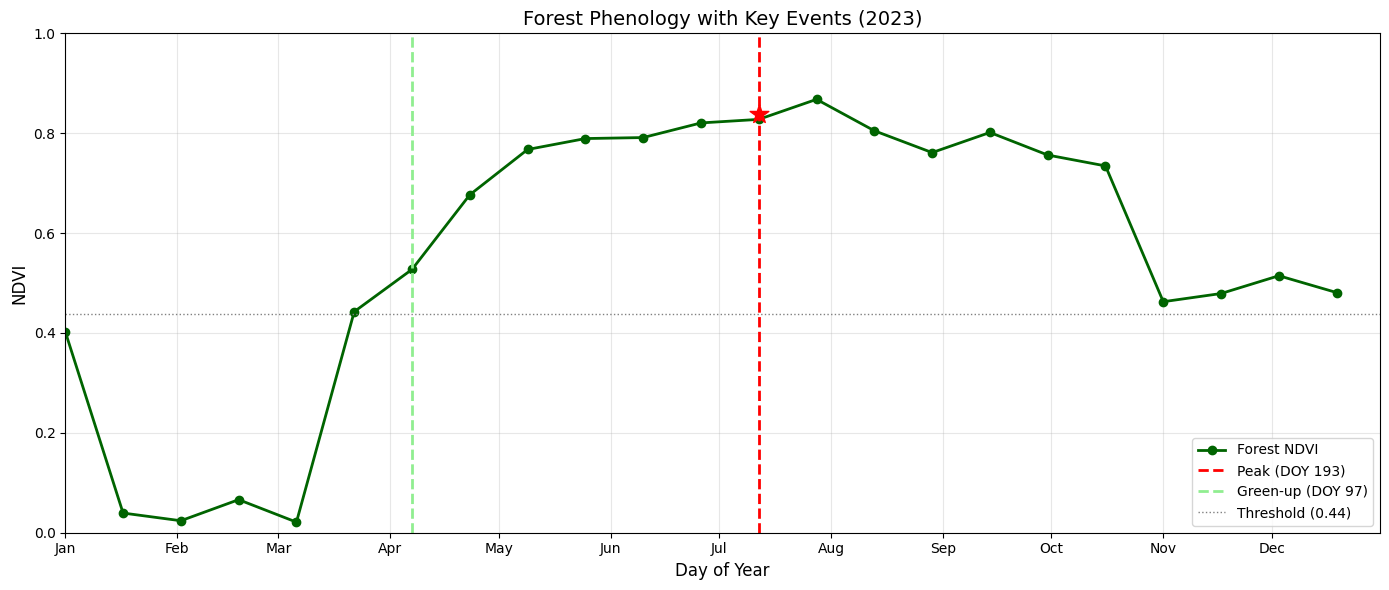

In [ ]:
# Visualize phenological events on the time series
fig, ax = plt.subplots(figsize=(14, 6))

# Plot forest phenology with annotations
forest_df = df[df['name'] == 'Forest (Arboretum)'].sort_values('date')
ax.plot(forest_df['doy'], forest_df['NDVI'], 'o-', color='darkgreen',
        linewidth=2, markersize=6, label='Forest NDVI')

# Add phenological markers
m = all_metrics['Forest (Arboretum)']

# Peak
ax.axvline(m['peak_doy'], color='red', linestyle='--', linewidth=2, label=f"Peak (DOY {m['peak_doy']})")
ax.scatter([m['peak_doy']], [m['peak_ndvi']], s=200, c='red', zorder=5, marker='*')

# SOS
if 'sos_doy' in m:
    ax.axvline(m['sos_doy'], color='lightgreen', linestyle='--', linewidth=2, label=f"Green-up (DOY {m['sos_doy']})")

# EOS
if 'eos_doy' in m:
    ax.axvline(m['eos_doy'], color='orange', linestyle='--', linewidth=2, label=f"Senescence (DOY {m['eos_doy']})")

# Threshold line
threshold = m['min_ndvi'] + 0.5 * m['amplitude']
ax.axhline(threshold, color='gray', linestyle=':', linewidth=1, label=f"Threshold ({threshold:.2f})")

ax.set_xlabel('Day of Year', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Forest Phenology with Key Events (2023)', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 365)
ax.set_ylim(0, 1)

# Month labels
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks(month_starts)
ax.set_xticklabels(month_names)

plt.tight_layout()
plt.show()

### 2.4 Multi-Year Phenology Comparison

In [ ]:
# Compare phenology across multiple years at forest site
years = [2019, 2020, 2021, 2022, 2023]
multi_year_data = []

for year in years:
    print(f"Processing {year}...", end=' ')

    modis_year = (modis
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filterBounds(forest_point)
        .select('NDVI')
        .map(scale_modis)
    )

    # Get list of images
    image_list = modis_year.toList(modis_year.size())
    n_images = modis_year.size().getInfo()

    for i in range(n_images):
        image = ee.Image(image_list.get(i))

        # Get day of year
        doy = image.date().getRelative('day', 'year').getInfo() + 1

        # Extract NDVI
        ndvi = image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=forest_point,
            scale=250
        ).get('NDVI').getInfo()

        if ndvi is not None:
            multi_year_data.append({'doy': doy, 'ndvi': ndvi, 'year': year})

    print(f"done ({n_images} images)")

df_multi = pd.DataFrame(multi_year_data)
print(f"\nMulti-year data: {len(df_multi)} observations")

Processing 2019... done (23 images)
Processing 2020... done (23 images)
Processing 2021... done (23 images)
Processing 2022... done (23 images)
Processing 2023... done (23 images)

Multi-year data: 115 observations


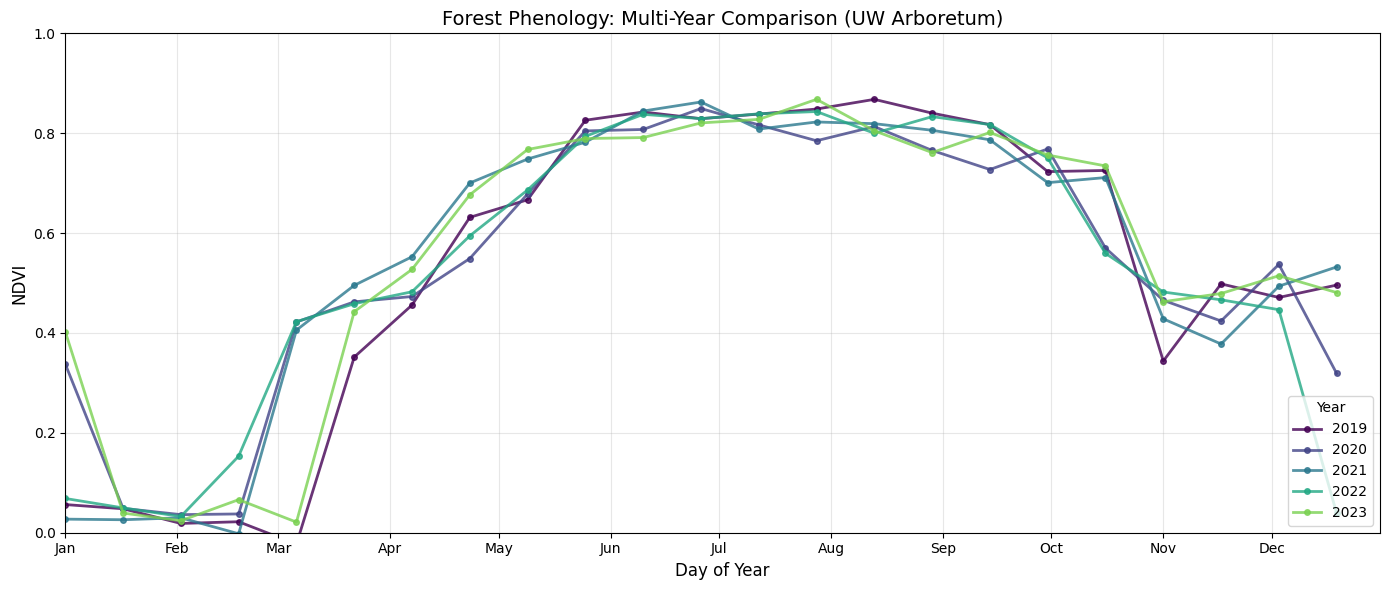

In [ ]:
# Plot multi-year comparison
fig, ax = plt.subplots(figsize=(14, 6))

cmap = plt.cm.viridis
colors = {year: cmap(i / len(years)) for i, year in enumerate(years)}

for year in years:
    subset = df_multi[df_multi['year'] == year].sort_values('doy')
    ax.plot(subset['doy'], subset['ndvi'], 'o-', label=str(year),
            color=colors[year], linewidth=2, markersize=4, alpha=0.8)

ax.set_xlabel('Day of Year', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Forest Phenology: Multi-Year Comparison (UW Arboretum)', fontsize=14)
ax.legend(title='Year', loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 365)
ax.set_ylim(0, 1)

ax.set_xticks(month_starts)
ax.set_xticklabels(month_names)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate phenology metrics for each year
print("\nForest Phenology Trends (2019-2023):")
print("=" * 55)
print(f"{'Year':<6} {'Peak DOY':>10} {'Peak NDVI':>12} {'SOS DOY':>10} {'EOS DOY':>10}")
print("-" * 55)

yearly_metrics = []

for year in years:
    df_year = df_multi[df_multi['year'] == year].copy()
    df_year['date'] = pd.to_datetime(df_year['doy'].apply(lambda x: f'{year}-{int(x):03d}'), format='%Y-%j')
    df_year = df_year.rename(columns={'ndvi': 'NDVI'})

    m = extract_phenology_metrics(df_year)
    yearly_metrics.append({'year': year, **m})

    sos = m.get('sos_doy', 'N/A')
    eos = m.get('eos_doy', 'N/A')
    print(f"{year:<6} {m['peak_doy']:>10} {m['peak_ndvi']:>12.3f} {str(sos):>10} {str(eos):>10}")

# Check for trends
df_metrics = pd.DataFrame(yearly_metrics)
if 'sos_doy' in df_metrics.columns:
    sos_trend = df_metrics['sos_doy'].diff().mean()
    print(f"\nAverage SOS change per year: {sos_trend:+.1f} days")


Forest Phenology Trends (2019-2023):
Year     Peak DOY    Peak NDVI    SOS DOY    EOS DOY
-------------------------------------------------------
2019          225        0.852         97        N/A
2020          177        0.825         81        N/A
2021          177        0.838         81        N/A
2022          193        0.837         81        N/A
2023          193        0.839         97        N/A

Average SOS change per year: +0.0 days


### 2.5 Spatial Phenology Patterns

In [ ]:
# Create spatial map of peak NDVI timing
def add_doy(image):
    """Add day of year as a band."""
    doy = ee.Number(image.date().getRelative('day', 'year')).add(1)
    return image.addBands(ee.Image.constant(doy).rename('DOY').toInt())

# Add DOY to each image
modis_with_doy = modis_2023.map(add_doy)

# Get peak NDVI date using qualityMosaic
peak_doy_image = modis_with_doy.qualityMosaic('NDVI').select('DOY').clip(dane_county)

# Get maximum NDVI value
max_ndvi_image = modis_2023.max().clip(dane_county)

In [ ]:
# Visualize spatial phenology
Map = geemap.Map(center=[43.1, -89.4], zoom=10)

# Peak NDVI value
Map.addLayer(max_ndvi_image,
             {'min': 0.3, 'max': 0.9, 'palette': ['brown', 'yellow', 'lightgreen', 'green', 'darkgreen']},
             'Peak NDVI Value')

# Day of peak (timing)
Map.addLayer(peak_doy_image,
             {'min': 150, 'max': 250, 'palette': ['purple', 'blue', 'cyan', 'green', 'yellow', 'orange', 'red']},
             'Day of Peak NDVI')

Map.add_colorbar({'min': 150, 'max': 250,
                  'palette': ['purple', 'blue', 'cyan', 'green', 'yellow', 'orange', 'red']},
                 label='Day of Year (Peak NDVI)')

Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

---
## 3. Exercise

Based on the phenology analysis:

1. Which land cover type (Forest, Agriculture, Urban) has the **longest growing season**?
2. Which has the **highest peak NDVI**?
3. Why might agricultural land show a different phenological pattern than forest?

Hint: Consider planting dates, harvest, and natural vs managed vegetation.

In [ ]:
# Your analysis here


---
## Summary

### Land Cover Products

| Product | Use Case |
|---------|----------|
| **NLCD** | Detailed US land cover analysis (30m) |
| **ESA WorldCover** | Global analysis (10m) |
| **MODIS Land Cover** | Large-scale, annual change |

### Phenology Metrics

| Metric | Definition | Ecological Significance |
|--------|------------|-------------------------|
| Start of Season (SOS) | Green-up date | Leaf emergence, spring onset |
| Peak NDVI | Maximum greenness | Full canopy development |
| End of Season (EOS) | Senescence date | Leaf drop, dormancy onset |
| Growing Season Length | EOS - SOS | Carbon uptake period |
| Amplitude | Peak - Min NDVI | Seasonal contrast, deciduousness |

### Key GEE Operations

| Task | Code |
|------|------|
| Load land cover | `ee.Image('USGS/NLCD_RELEASES/2021_REL/NLCD/2021')` |
| Reclassify | `image.remap(from_list, to_list)` |
| Create mask | `image.eq(value)` |
| Area by class | `reduceRegion(ee.Reducer.sum().group())` |
| Peak timing | `collection.qualityMosaic('NDVI')` |
| Time series extraction | `image.reduceRegion()` in loop |

---
## Solution

In [ ]:
# Exercise Solution

print("Phenology Comparison:")
print("=" * 50)

for name, m in all_metrics.items():
    gsl = m.get('growing_season_length', 'N/A')
    print(f"{name}:")
    print(f"  Peak NDVI: {m['peak_ndvi']:.3f}")
    print(f"  Growing Season: {gsl} days\n")

print("\nInterpretation:")
print("-" * 50)
print("1. Forest typically has the longest growing season")
print("   - Natural vegetation follows climate signals")
print("   - Gradual green-up and senescence")
print("")
print("2. Agriculture often has highest peak NDVI")
print("   - Crops are bred for maximum productivity")
print("   - Dense monocultures at peak growth")
print("")
print("3. Agriculture differs from forest because:")
print("   - Later start (planting after last frost)")
print("   - Abrupt end (harvest removes vegetation)")
print("   - Sharp NDVI drop vs gradual forest senescence")
print("   - Different crops peak at different times")

Phenology Comparison:
Forest (Arboretum):
  Peak NDVI: 0.839
  Growing Season: N/A days

Agriculture:
  Peak NDVI: 0.851
  Growing Season: N/A days

Urban (Madison):
  Peak NDVI: 0.372
  Growing Season: 208 days


Interpretation:
--------------------------------------------------
1. Forest typically has the longest growing season
   - Natural vegetation follows climate signals
   - Gradual green-up and senescence

2. Agriculture often has highest peak NDVI
   - Crops are bred for maximum productivity
   - Dense monocultures at peak growth

3. Agriculture differs from forest because:
   - Later start (planting after last frost)
   - Abrupt end (harvest removes vegetation)
   - Sharp NDVI drop vs gradual forest senescence
   - Different crops peak at different times
